# Rakuen Kamata prediction-data quality audit

A reproducible first-pass audit of the repository data used to analyze and forecast 楽園蒲田店. The source databases are read-only; no model is retrained here.

In [1]:
from __future__ import annotations

import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

AUDIT_AS_OF = pd.Timestamp("2026-09-12")
HALL_NAME = "楽園蒲田店"

def find_project_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "db" / f"{HALL_NAME}.db").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root and Rakuen database")

PROJECT_ROOT = find_project_root()
HALL_DB = PROJECT_ROOT / "db" / f"{HALL_NAME}.db"
ANALYSIS_DB = PROJECT_ROOT / "db" / "analysis_results.db"

with sqlite3.connect(HALL_DB) as connection:
    raw = pd.read_sql_query(
        """
        SELECT date, machine_number, machine_name, last_digit, is_zorome,
               machine_rank_in_type, games_normalized, diff_coins_normalized,
               bb_count, rb_count, rb_probability_decimal
        FROM machine_detailed_results
        """,
        connection,
    )
    daily = pd.read_sql_query("SELECT * FROM daily_hall_summary", connection)
    master = pd.read_sql_query(
        """
        SELECT machine_name_normalized, jug_flag, hana_flag, oki_flag, bt_flag,
               game_type, spec_category, bonus_judgeable
        FROM machine_master
        """,
        connection,
    )
    layout = pd.read_sql_query("SELECT * FROM machine_layout_history", connection)
    current_layout = pd.read_sql_query("SELECT * FROM machine_layout", connection)
    layout_match = pd.read_sql_query(
        """
        WITH match_counts AS (
            SELECT r.date, r.machine_number, COUNT(h.machine_number) AS n_matches
            FROM machine_detailed_results AS r
            LEFT JOIN machine_layout_history AS h
              ON h.machine_number = r.machine_number
             AND r.date >= h.valid_from
             AND (h.valid_to IS NULL OR r.date <= h.valid_to)
            GROUP BY r.date, r.machine_number
        )
        SELECT COUNT(*) AS total_rows,
               SUM(n_matches = 0) AS no_match_rows,
               SUM(n_matches > 1) AS multi_match_rows
        FROM match_counts
        """,
        connection,
    ).iloc[0]

with sqlite3.connect(ANALYSIS_DB) as connection:
    external_reports = pd.read_sql_query(
        """
        SELECT report_id, source, business_date, event_name, target_machines,
               total_machines, target_pct, target_mean_diff, hall_total_diff
        FROM external_result_reports
        WHERE hall_name = ?
        """,
        connection,
        params=[HALL_NAME],
    )
    external_machines = pd.read_sql_query(
        """
        SELECT m.report_id, m.machine_number, m.actual_name, m.granularity,
               m.name_agrees, r.business_date
        FROM external_result_machines AS m
        JOIN external_result_reports AS r USING (report_id)
        WHERE r.hall_name = ?
        """,
        connection,
        params=[HALL_NAME],
    )
    external_models = pd.read_sql_query(
        """
        SELECT m.report_id, m.granularity, m.model_name, m.n_target, m.n_total,
               m.mean_diff, r.business_date
        FROM external_result_models AS m
        JOIN external_result_reports AS r USING (report_id)
        WHERE r.hall_name = ?
        """,
        connection,
        params=[HALL_NAME],
    )

for frame in (raw, daily, external_reports, external_machines, external_models):
    if "date" in frame.columns:
        frame["date_dt"] = pd.to_datetime(frame["date"], format="%Y%m%d", errors="coerce")
    if "business_date" in frame.columns:
        frame["business_date_dt"] = pd.to_datetime(frame["business_date"], format="%Y%m%d", errors="coerce")

raw["date_dt"] = pd.to_datetime(raw["date"], format="%Y%m%d", errors="coerce")
daily["date_dt"] = pd.to_datetime(daily["date"], format="%Y%m%d", errors="coerce")
latest_date = raw["date_dt"].max()
earliest_date = raw["date_dt"].min()

raw_by_day = (
    raw.groupby(["date", "date_dt"], as_index=False)
       .agg(
           raw_machines=("machine_number", "size"),
           raw_total_games=("games_normalized", "sum"),
           raw_total_diff=("diff_coins_normalized", "sum"),
           zero_games=("games_normalized", lambda s: int(s.eq(0).sum())),
       )
)

reconciliation = raw_by_day.merge(
    daily[["date", "total_machines", "total_games", "total_diff_coins"]],
    on="date",
    how="outer",
    indicator=True,
)
reconciliation["machine_count_diff"] = reconciliation["raw_machines"] - reconciliation["total_machines"]
reconciliation["game_total_diff"] = reconciliation["raw_total_games"] - reconciliation["total_games"]
reconciliation["coin_total_diff"] = reconciliation["raw_total_diff"] - reconciliation["total_diff_coins"]

raw_master = raw.merge(
    master,
    left_on="machine_name",
    right_on="machine_name_normalized",
    how="left",
    indicator=True,
)
recent_cutoff = latest_date - pd.Timedelta(days=89)
recent_master = raw_master[raw_master["date_dt"] >= recent_cutoff]

calendar = pd.date_range(earliest_date, latest_date, freq="D")
missing_calendar_dates = calendar.difference(pd.DatetimeIndex(raw["date_dt"].dropna().unique()))
external_date_set = set(external_reports["business_date"].dropna().astype(str))
derived_validation_path = PROJECT_ROOT / "data" / "corner_rank_prediction_by_section" / "corner_rank_prediction_by_section_validation.csv"
derived_date_set = set()
if derived_validation_path.exists():
    derived_date_set = set(
        pd.read_csv(derived_validation_path, usecols=["date"], dtype={"date": str})["date"].dropna()
    )
missing_date_evidence = pd.DataFrame(
    [
        {
            "missing_date": missing_date.strftime("%Y-%m-%d"),
            "external_result_exists": missing_date.strftime("%Y%m%d") in external_date_set,
            "derived_validation_rows_exist": missing_date.strftime("%Y%m%d") in derived_date_set,
        }
        for missing_date in missing_calendar_dates
    ]
)

recent_start = latest_date - pd.Timedelta(days=59)
recent_partial_days = raw_by_day[
    raw_by_day["date_dt"].ge(recent_start)
    & raw_by_day["raw_machines"].lt(len(current_layout))
].copy()
recent_partial_days["machine_shortfall_vs_current_layout"] = (
    len(current_layout) - recent_partial_days["raw_machines"]
)

sep6_ids = set(raw.loc[raw["date"].eq("20260906"), "machine_number"])
sep5_ids = set(raw.loc[raw["date"].eq("20260905"), "machine_number"])
sep7_ids = set(raw.loc[raw["date"].eq("20260907"), "machine_number"])
sep6_missing_machine_ids = sorted((sep5_ids & sep7_ids) - sep6_ids)

quality_metrics = {
    "rows": len(raw),
    "days": raw["date"].nunique(),
    "earliest_date": earliest_date.date().isoformat(),
    "latest_date": latest_date.date().isoformat(),
    "freshness_lag_days": int((AUDIT_AS_OF - latest_date).days),
    "duplicate_key_rows": int(raw.duplicated(["date", "machine_number"], keep=False).sum()),
    "exact_duplicate_rows": int(raw.duplicated(keep=False).sum()),
    "missing_core_rows": int(raw[["date", "machine_number", "machine_name", "games_normalized", "diff_coins_normalized"]].isna().any(axis=1).sum()),
    "negative_games_rows": int(raw["games_normalized"].lt(0).sum()),
    "zero_games_pct": float(raw["games_normalized"].eq(0).mean() * 100),
    "missing_calendar_dates": len(missing_calendar_dates),
    "confirmed_missing_dates": int(
        missing_date_evidence[["external_result_exists", "derived_validation_rows_exist"]].any(axis=1).sum()
    ),
    "recent_partial_days": len(recent_partial_days),
    "largest_recent_machine_shortfall": int(recent_partial_days["machine_shortfall_vs_current_layout"].max()) if len(recent_partial_days) else 0,
    "daily_reconciliation_failures": int(
        ((reconciliation["_merge"] != "both")
         | reconciliation[["machine_count_diff", "game_total_diff", "coin_total_diff"]].fillna(1).ne(0).any(axis=1)).sum()
    ),
    "master_unmapped_all_pct": float(raw_master["_merge"].eq("left_only").mean() * 100),
    "master_unmapped_recent_pct": float(recent_master["_merge"].eq("left_only").mean() * 100),
    "layout_no_match_pct": float(layout_match["no_match_rows"] / layout_match["total_rows"] * 100),
    "layout_multi_match_pct": float(layout_match["multi_match_rows"] / layout_match["total_rows"] * 100),
    "current_layout_rows": len(current_layout),
    "latest_raw_machines": int(raw.loc[raw["date_dt"].eq(latest_date), "machine_number"].nunique()),
    "external_report_count": len(external_reports),
    "external_report_days": int(external_reports["business_date"].nunique()),
    "external_machine_labels": len(external_machines),
    "external_model_labels": len(external_models),
}

monthly = (
    raw_master.assign(month=raw_master["date_dt"].dt.to_period("M").astype(str))
    .groupby("month", as_index=False)
    .agg(
        days=("date", "nunique"),
        machine_days=("machine_number", "size"),
        avg_machines_per_day=("machine_number", lambda s: len(s) / raw_master.loc[s.index, "date"].nunique()),
        zero_games_pct=("games_normalized", lambda s: s.eq(0).mean() * 100),
        avg_games=("games_normalized", "mean"),
        avg_diff=("diff_coins_normalized", "mean"),
        master_unmapped_pct=("_merge", lambda s: s.eq("left_only").mean() * 100),
    )
)

daily_quality = raw_by_day.copy()
daily_quality["zero_games_pct"] = daily_quality["zero_games"] / daily_quality["raw_machines"] * 100

quality_metrics

{'rows': 349086,
 'days': 615,
 'earliest_date': '2025-01-01',
 'latest_date': '2026-09-10',
 'freshness_lag_days': 2,
 'duplicate_key_rows': 0,
 'exact_duplicate_rows': 0,
 'missing_core_rows': 0,
 'negative_games_rows': 0,
 'zero_games_pct': 7.729900368390597,
 'missing_calendar_dates': 3,
 'confirmed_missing_dates': 2,
 'recent_partial_days': 1,
 'largest_recent_machine_shortfall': 13,
 'daily_reconciliation_failures': 0,
 'master_unmapped_all_pct': 0.0,
 'master_unmapped_recent_pct': 0.0,
 'layout_no_match_pct': 0.0,
 'layout_multi_match_pct': 0.0,
 'current_layout_rows': 587,
 'latest_raw_machines': 587,
 'external_report_count': 49,
 'external_report_days': 46,
 'external_machine_labels': 1528,
 'external_model_labels': 369}

## tl;dr

In [2]:
summary_lines = [
    f"- **Usable core grain:** {quality_metrics['rows']:,} machine-day rows across {quality_metrics['days']} days; duplicate `(date, machine_number)` rows = {quality_metrics['duplicate_key_rows']:,}.",
    f"- **Freshness:** latest result date is {quality_metrics['latest_date']} ({quality_metrics['freshness_lag_days']} days behind the fixed audit date).",
    f"- **Aggregate integrity:** daily summary reconciliation failures = {quality_metrics['daily_reconciliation_failures']}.",
    f"- **Completeness failure:** {quality_metrics['confirmed_missing_dates']} missing dates are corroborated by another project artifact, and {quality_metrics['recent_partial_days']} recent day has fewer machine rows than the current floor roster.",
    f"- **Reference joins:** recent machine-master unmapped rate = {quality_metrics['master_unmapped_recent_pct']:.2f}%; layout rows with no effective-dated match = {quality_metrics['layout_no_match_pct']:.2f}%.",
    f"- **Ground-truth constraint:** external result labels cover {quality_metrics['external_report_days']} distinct days, so they are valuable but not a complete daily target.",
]
display(Markdown("\n".join(summary_lines)))

- **Usable core grain:** 349,086 machine-day rows across 615 days; duplicate `(date, machine_number)` rows = 0.
- **Freshness:** latest result date is 2026-09-10 (2 days behind the fixed audit date).
- **Aggregate integrity:** daily summary reconciliation failures = 0.
- **Completeness failure:** 2 missing dates are corroborated by another project artifact, and 1 recent day has fewer machine rows than the current floor roster.
- **Reference joins:** recent machine-master unmapped rate = 0.00%; layout rows with no effective-dated match = 0.00%.
- **Ground-truth constraint:** external result labels cover 46 distinct days, so they are valuable but not a complete daily target.

## Context & Methods

### Key assumptions

- The intended fact-table grain is one row per business date and machine number.
- `machine_detailed_results` is the controlling machine-day source; daily summaries are reconciled against it.
- `machine_master` is joined exactly on the stored normalized machine name. An unmapped historical name may reflect a retired machine rather than ingestion failure.
- A layout record is valid when the business date lies within its inclusive effective-date interval.
- External result reports are treated as sparse observed labels, not a complete census of high-setting machines.

## Data

In [3]:
dataset_summary = pd.DataFrame([
    {"dataset": "machine_detailed_results", "grain": "date × machine", "rows": len(raw), "min_date": quality_metrics["earliest_date"], "max_date": quality_metrics["latest_date"]},
    {"dataset": "daily_hall_summary", "grain": "date", "rows": len(daily), "min_date": daily["date_dt"].min().date().isoformat(), "max_date": daily["date_dt"].max().date().isoformat()},
    {"dataset": "machine_master", "grain": "normalized machine name", "rows": len(master), "min_date": None, "max_date": None},
    {"dataset": "machine_layout_history", "grain": "machine × effective interval", "rows": len(layout), "min_date": layout["valid_from"].min(), "max_date": layout["valid_to"].dropna().max()},
    {"dataset": "external_result_reports", "grain": "published result report", "rows": len(external_reports), "min_date": external_reports["business_date_dt"].min().date().isoformat() if len(external_reports) else None, "max_date": external_reports["business_date_dt"].max().date().isoformat() if len(external_reports) else None},
])
dataset_summary

,dataset,grain,rows,min_date,max_date
0,machine_detailed_results,date × machine,349086,2025-01-01,2026-09-10
1,daily_hall_summary,date,615,2025-01-01,2026-09-10
2,machine_master,normalized machine name,277,NaN,NaN
3,machine_layout_history,machine × effective interval,1154,20250101,20260705
4,external_result_reports,published result report,49,2026-07-01,2026-09-05


## Results

In [4]:
checks = pd.DataFrame([
    {"check": "Duplicate machine-day keys", "result": quality_metrics["duplicate_key_rows"], "unit": "rows", "severity_if_nonzero": "Critical"},
    {"check": "Missing core fields", "result": quality_metrics["missing_core_rows"], "unit": "rows", "severity_if_nonzero": "High"},
    {"check": "Negative game counts", "result": quality_metrics["negative_games_rows"], "unit": "rows", "severity_if_nonzero": "High"},
    {"check": "Missing calendar dates", "result": quality_metrics["missing_calendar_dates"], "unit": "dates", "severity_if_nonzero": "High when independently corroborated"},
    {"check": "Corroborated missing dates", "result": quality_metrics["confirmed_missing_dates"], "unit": "dates", "severity_if_nonzero": "High"},
    {"check": "Recent partial-ingestion days", "result": quality_metrics["recent_partial_days"], "unit": "dates", "severity_if_nonzero": "High"},
    {"check": "Daily summary reconciliation failures", "result": quality_metrics["daily_reconciliation_failures"], "unit": "dates", "severity_if_nonzero": "High"},
    {"check": "Recent master-unmapped rate", "result": quality_metrics["master_unmapped_recent_pct"], "unit": "%", "severity_if_nonzero": "High when material"},
    {"check": "Layout no-match rate", "result": quality_metrics["layout_no_match_pct"], "unit": "%", "severity_if_nonzero": "High for position models"},
    {"check": "Layout multi-match rate", "result": quality_metrics["layout_multi_match_pct"], "unit": "%", "severity_if_nonzero": "Critical"},
])
checks.round({"result": 3})

,check,result,unit,severity_if_nonzero
0,Duplicate machine-day keys,0.0,rows,Critical
1,Missing core fields,0.0,rows,High
2,Negative game counts,0.0,rows,High
3,Missing calendar dates,3.0,dates,High when independently corroborated
4,Corroborated missing dates,2.0,dates,High
5,Recent partial-ingestion days,1.0,dates,High
6,Daily summary reconciliation failures,0.0,dates,High
7,Recent master-unmapped rate,0.0,%,High when material
8,Layout no-match rate,0.0,%,High for position models
9,Layout multi-match rate,0.0,%,Critical


In [5]:
unmapped_recent = (
    recent_master.loc[recent_master["_merge"].eq("left_only"), ["machine_name", "date"]]
    .groupby("machine_name", as_index=False)
    .agg(machine_days=("date", "size"), first_date=("date", "min"), last_date=("date", "max"))
    .sort_values("machine_days", ascending=False)
)
display(Markdown("### Missing calendar dates"))
display(missing_date_evidence)
display(Markdown("### Recent partial-ingestion days"))
display(recent_partial_days[["date", "raw_machines", "machine_shortfall_vs_current_layout"]])
display(Markdown(f"On 2026-09-06, machines present on both adjacent days but absent that day: `{sep6_missing_machine_ids}`"))
display(Markdown("### Recent unmapped machine names"))
display(unmapped_recent.head(20))

### Missing calendar dates

,missing_date,external_result_exists,derived_validation_rows_exist
0,2025-04-10,False,True
1,2026-07-08,False,False
2,2026-07-11,True,False


### Recent partial-ingestion days

,date,raw_machines,machine_shortfall_vs_current_layout
610,20260906,574,13


On 2026-09-06, machines present on both adjacent days but absent that day: `[3202, 3203, 3204, 3205, 3206, 3207, 3208, 3209, 3210, 3211, 3212, 3213, 3214]`

### Recent unmapped machine names

,machine_name,machine_days,first_date,last_date


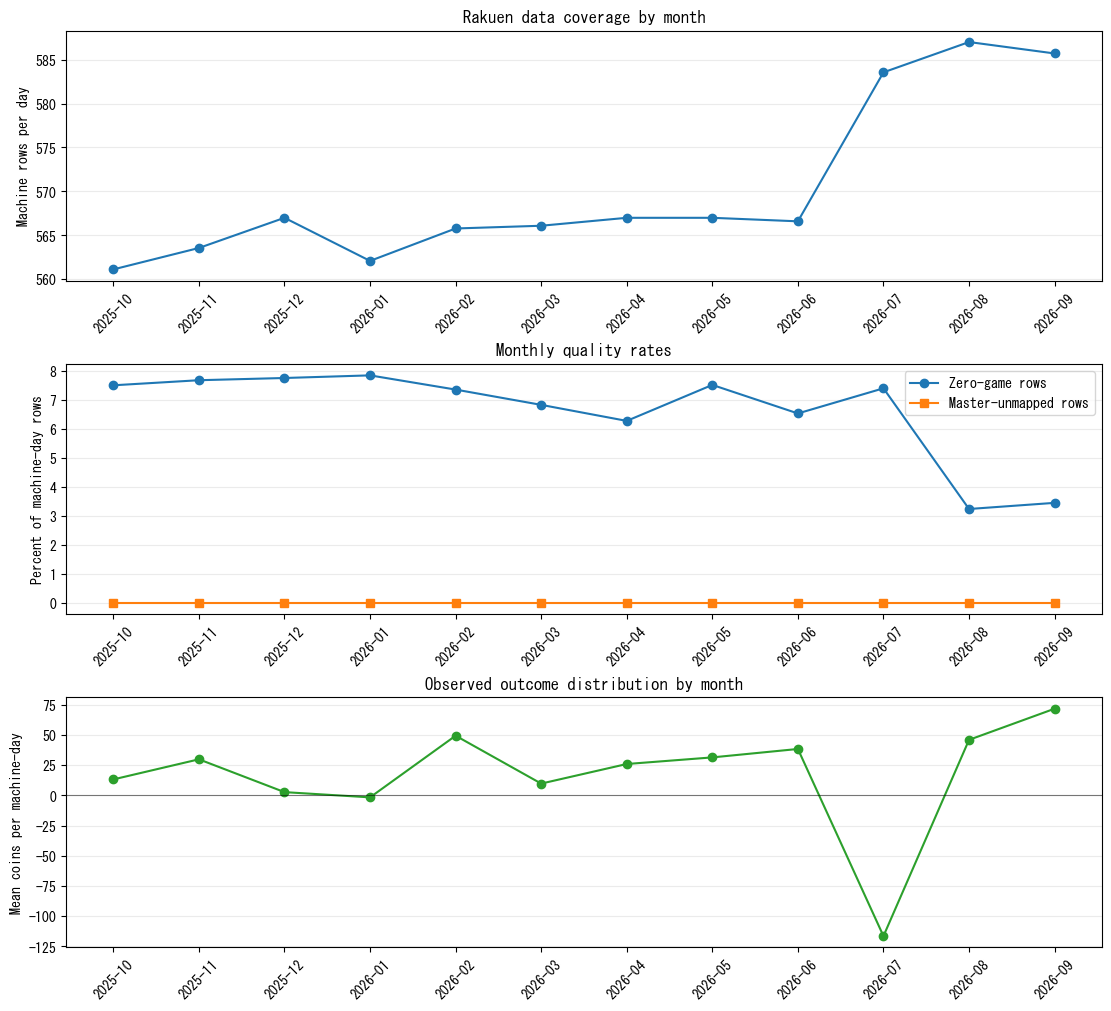

,month,days,machine_days,avg_machines_per_day,zero_games_pct,avg_games,avg_diff,master_unmapped_pct
9,2025-10,31,17395,561.13,7.51,2550.04,13.32,0.0
10,2025-11,30,16907,563.57,7.68,2655.83,29.97,0.0
11,2025-12,31,17577,567.00,7.76,2527.45,2.79,0.0
12,2026-01,31,17425,562.10,7.85,2731.06,-1.55,0.0
13,2026-02,28,15842,565.79,7.36,2993.52,49.53,0.0
14,2026-03,31,17549,566.10,6.83,2829.10,9.85,0.0
15,2026-04,30,17010,567.00,6.28,2810.74,26.08,0.0
16,2026-05,31,17577,567.00,7.52,3034.98,31.56,0.0
17,2026-06,30,16998,566.60,6.54,2826.17,38.54,0.0
18,2026-07,29,16923,583.55,7.40,3188.93,-116.47,0.0


In [6]:
recent_monthly = monthly.tail(12).copy()
fig, axes = plt.subplots(3, 1, figsize=(11, 10), constrained_layout=True)

axes[0].plot(recent_monthly["month"], recent_monthly["avg_machines_per_day"], marker="o", label="Machines/day")
axes[0].set_title("Rakuen data coverage by month")
axes[0].set_ylabel("Machine rows per day")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.25)

axes[1].plot(recent_monthly["month"], recent_monthly["zero_games_pct"], marker="o", label="Zero-game rows")
axes[1].plot(recent_monthly["month"], recent_monthly["master_unmapped_pct"], marker="s", label="Master-unmapped rows")
axes[1].set_title("Monthly quality rates")
axes[1].set_ylabel("Percent of machine-day rows")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend()

axes[2].plot(recent_monthly["month"], recent_monthly["avg_diff"], marker="o", color="tab:green")
axes[2].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[2].set_title("Observed outcome distribution by month")
axes[2].set_ylabel("Mean coins per machine-day")
axes[2].tick_params(axis="x", rotation=45)
axes[2].grid(axis="y", alpha=0.25)

plt.show()
recent_monthly.round(2)

In [7]:
label_summary = pd.DataFrame([
    {"label_source": "External reports", "rows": len(external_reports), "distinct_dates": external_reports["business_date"].nunique()},
    {"label_source": "External machine labels", "rows": len(external_machines), "distinct_dates": external_machines["business_date"].nunique()},
    {"label_source": "External model labels", "rows": len(external_models), "distinct_dates": external_models["business_date"].nunique()},
])
label_summary

,label_source,rows,distinct_dates
0,External reports,49,46
1,External machine labels,1528,41
2,External model labels,369,46


## Takeaways

In [8]:
takeaways = []
if quality_metrics["duplicate_key_rows"] == 0 and quality_metrics["daily_reconciliation_failures"] == 0:
    takeaways.append("- **Key uniqueness is sound, but aggregate reconciliation is not an independent completeness check:** the daily summary is consistent with the same incomplete machine-day source.")
if quality_metrics["confirmed_missing_dates"] > 0:
    takeaways.append(f"- **High-severity historical gaps:** {quality_metrics['confirmed_missing_dates']} missing dates are independently corroborated. Exclude or restore them before walk-forward training and evaluation.")
if quality_metrics["recent_partial_days"] > 0:
    takeaways.append(f"- **High-severity partial ingestion:** a recent day is short by up to {quality_metrics['largest_recent_machine_shortfall']} machines; 2026-09-06 loses one contiguous 13-machine block and should fail a preflight coverage gate.")
if quality_metrics["freshness_lag_days"] > 1:
    takeaways.append(f"- **Freshness risk:** the database ends {quality_metrics['freshness_lag_days']} days before the audit date; never score a target without freezing and reporting `data_asof`.")
takeaways.append(f"- **Outcome drift:** monthly mean coins per machine-day moved from {monthly.loc[monthly['month'].eq('2026-07'), 'avg_diff'].iloc[0]:.1f} in 2026-07 to {monthly.loc[monthly['month'].eq('2026-08'), 'avg_diff'].iloc[0]:.1f} in 2026-08. Treat this as a regime or measurement-change alert until independently explained.")
if quality_metrics["layout_no_match_pct"] > 0 or quality_metrics["layout_multi_match_pct"] > 0:
    takeaways.append(f"- **Position-feature risk:** {quality_metrics['layout_no_match_pct']:.2f}% of machine-days have no effective layout and {quality_metrics['layout_multi_match_pct']:.2f}% have multiple matches. Position models need an explicit eligibility gate.")
if quality_metrics["master_unmapped_recent_pct"] > 0:
    takeaways.append(f"- **Machine taxonomy risk:** {quality_metrics['master_unmapped_recent_pct']:.2f}% of recent machine-days do not map to the current master by exact name. Resolve aliases before category or specification models.")
takeaways.append(f"- **Label limitation:** published external results cover only {quality_metrics['external_report_days']} dates; use them as a high-quality sparse validation set, not as complete daily ground truth.")
takeaways.append("- **Next model step:** keep the repository's forward-test harness, then add automated preflight gates for freshness, master/layout coverage, and label availability before comparing challenger features.")
display(Markdown("\n".join(takeaways)))

- **Key uniqueness is sound, but aggregate reconciliation is not an independent completeness check:** the daily summary is consistent with the same incomplete machine-day source.
- **High-severity historical gaps:** 2 missing dates are independently corroborated. Exclude or restore them before walk-forward training and evaluation.
- **High-severity partial ingestion:** a recent day is short by up to 13 machines; 2026-09-06 loses one contiguous 13-machine block and should fail a preflight coverage gate.
- **Freshness risk:** the database ends 2 days before the audit date; never score a target without freezing and reporting `data_asof`.
- **Outcome drift:** monthly mean coins per machine-day moved from -116.5 in 2026-07 to 46.1 in 2026-08. Treat this as a regime or measurement-change alert until independently explained.
- **Label limitation:** published external results cover only 46 dates; use them as a high-quality sparse validation set, not as complete daily ground truth.
- **Next model step:** keep the repository's forward-test harness, then add automated preflight gates for freshness, master/layout coverage, and label availability before comparing challenger features.